In [5]:
import pandas as pd
import numpy as np

original_df =pd.read_csv("C:\\Users\\locos\\Documents\\CiampittiLab\\Publication_analysis\\New_work\\data\\openalex_output\\works.csv")
original_df.columns

Index(['openalex_id', 'openalex_url', 'doi', 'doi_registration_agency',
       'id_mag', 'id_pmid', 'id_pmcid', 'title', 'publication_year',
       'publication_date', 'type', 'type_crossref', 'language', 'indexed_in',
       'cited_by_count', 'fwci', 'citation_percentile_value',
       'is_in_top_1_percent', 'is_in_top_10_percent', 'counts_by_year',
       'cited_by_api_url', 'authors_count', 'countries_distinct_count',
       'institutions_distinct_count', 'corresponding_author_ids',
       'corresponding_institution_ids', 'queried_author_id',
       'queried_author_position', 'queried_author_is_corresponding',
       'queried_author_raw_name', 'queried_author_raw_affiliation', 'is_oa',
       'oa_status', 'oa_url', 'any_repository_has_fulltext', 'locations_count',
       'primary_location_is_oa', 'primary_location_version',
       'primary_location_license', 'primary_location_landing_url',
       'primary_location_pdf_url', 'source_id', 'source_display_name',
       'source_issn_l',

TARGET ANALYSIS
Loaded processed dataset with exact target columns from works_processed_for_ml.csv.
Selected target: citations_first_2y_exact
Rows analyzed: 787
Missing target values: 0 (0.00% of all rows)
IQR bounds: [-30.50, 61.50]
Outliers detected: 98 (12.45% of non-missing target rows)
Skewness: 10.546
Kurtosis: 171.334

Target summary:
        stat       value
       count  787.000000
        mean   32.846252
         std   84.544088
         min    0.000000
         25%    4.000000
         50%   12.000000
         75%   27.000000
         max 1634.000000
     missing    0.000000
outliers_iqr   98.000000


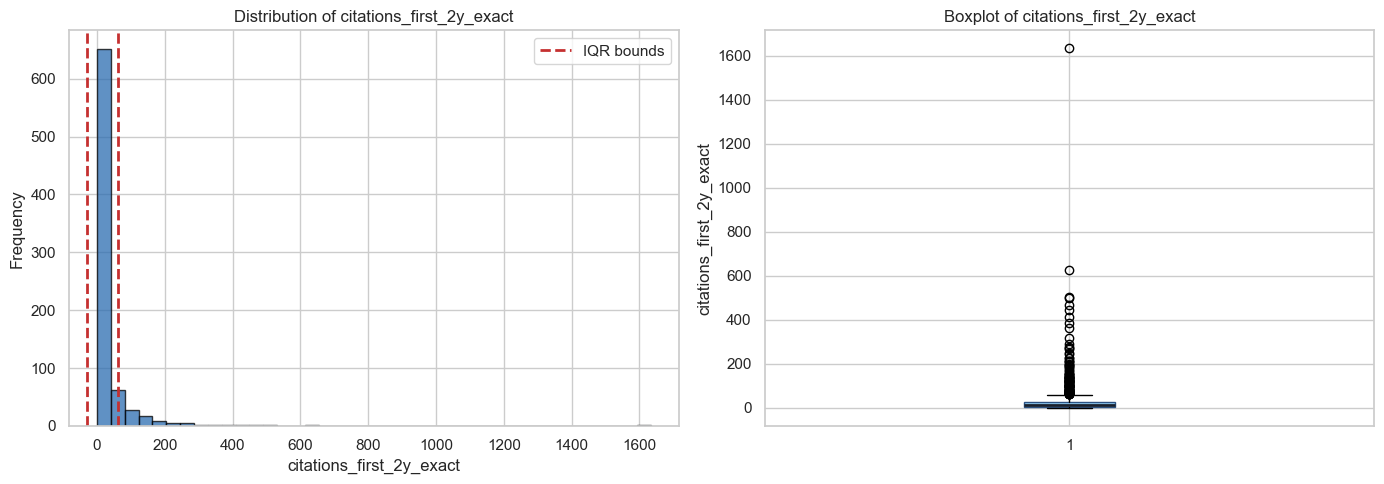

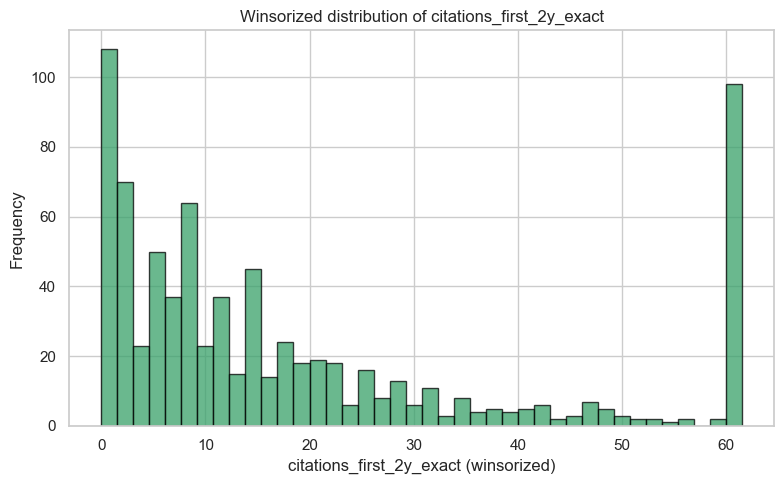

Recommendation: compare raw vs winsorized target in modeling; tree models may tolerate raw counts, while linear models often improve with capped extremes.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

EXACT_TARGET_CANDIDATES = [
    "citations_first_2y_exact",
    "normalized_2y_cites_exact",
    "citations_first_2y",
]
TARGET_CANDIDATES = EXACT_TARGET_CANDIDATES + ["cited_by_count", "total_citations"]

processed_path = Path(r"C:\Users\locos\Documents\CiampittiLab\Publication_analysis\New_work\data\openalex_output\works_processed_for_ml.csv")
analysis_df = original_df.copy()
source_note = "Using works.csv as the analysis source."

if not any(col in analysis_df.columns for col in EXACT_TARGET_CANDIDATES) and processed_path.exists():
    processed_df = pd.read_csv(processed_path, low_memory=False)
    if any(col in processed_df.columns for col in EXACT_TARGET_CANDIDATES):
        analysis_df = processed_df.copy()
        source_note = f"Loaded processed dataset with exact target columns from {processed_path.name}."

selected_target = next((col for col in TARGET_CANDIDATES if col in analysis_df.columns), None)
if selected_target is None:
    raise KeyError(
        "No citation target column was found. Checked: " + ", ".join(TARGET_CANDIDATES)
    )

# Keep a working copy for downstream cleaning decisions
df_clean = analysis_df.copy()

# Align target analysis with a numeric series
target_series = pd.to_numeric(df_clean[selected_target], errors="coerce")
missing_target_mask = target_series.isna()
complete_rows = df_clean.loc[~missing_target_mask].copy()

q1 = target_series.quantile(0.25)
q3 = target_series.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_mask = target_series.notna() & ((target_series < lower_bound) | (target_series > upper_bound))

analysis_rows = int(target_series.notna().sum())
missing_count = int(missing_target_mask.sum())
outlier_count = int(outlier_mask.sum())
outlier_share = outlier_count / analysis_rows if analysis_rows else np.nan
skewness = float(target_series.skew())
kurtosis = float(target_series.kurtosis())

print("=" * 80)
print("TARGET ANALYSIS")
print("=" * 80)
print(source_note)
print(f"Selected target: {selected_target}")
print(f"Rows analyzed: {analysis_rows}")
print(f"Missing target values: {missing_count} ({missing_count / len(df_clean):.2%} of all rows)")
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers detected: {outlier_count} ({outlier_share:.2%} of non-missing target rows)")
print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis: {kurtosis:.3f}")

summary_table = pd.DataFrame({
    "stat": [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "missing",
        "outliers_iqr",
    ],
    "value": [
        target_series.count(),
        target_series.mean(),
        target_series.std(),
        target_series.min(),
        q1,
        target_series.median(),
        q3,
        target_series.max(),
        missing_count,
        outlier_count,
    ],
})
print("\nTarget summary:")
print(summary_table.to_string(index=False))

# Create a winsorized version for downstream experimentation
winsorized_target = target_series.clip(lower=lower_bound, upper=upper_bound)
df_clean[f"{selected_target}_winsorized"] = winsorized_target
if selected_target != "citations_first_2y_exact" and "citations_first_2y_exact" not in df_clean.columns:
    df_clean["citations_first_2y_exact"] = target_series

df_clean["target_missing_flag"] = missing_target_mask.astype(int)
df_clean["target_outlier_flag"] = outlier_mask.astype(int)

# Keep only rows with a valid target for model-ready samples
complete_rows = df_clean.loc[target_series.notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(target_series.dropna(), bins=40, edgecolor="black", alpha=0.75, color="#2b6cb0")
axes[0].axvline(lower_bound, color="#c53030", linestyle="--", linewidth=2, label="IQR bounds")
axes[0].axvline(upper_bound, color="#c53030", linestyle="--", linewidth=2)
axes[0].set_title(f"Distribution of {selected_target}")
axes[0].set_xlabel(selected_target)
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].boxplot(
    target_series.dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#90cdf4", color="#2c5282"),
    medianprops=dict(color="#1a202c", linewidth=2),
)
axes[1].set_title(f"Boxplot of {selected_target}")
axes[1].set_ylabel(selected_target)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(winsorized_target.dropna(), bins=40, edgecolor="black", alpha=0.75, color="#38a169")
plt.title(f"Winsorized distribution of {selected_target}")
plt.xlabel(f"{selected_target} (winsorized)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Quick recommendation summary
if missing_count > 0:
    print("\nRecommendation: drop rows with missing target before training; imputing the target is not appropriate for supervised learning.")
if outlier_count > 0:
    print("Recommendation: compare raw vs winsorized target in modeling; tree models may tolerate raw counts, while linear models often improve with capped extremes.")
else:
    print("Recommendation: target outlier burden is limited under the IQR rule; raw target may be acceptable after a log1p sensitivity check.")


PERCENTILE-BASED TARGET TREATMENT
Target: citations_first_2y_exact
Lower percentile: 0% -> 0.00
Upper percentile: 95% -> 137.70
Zero-citation papers kept: 76 (9.66% of all rows)
Rows trimmed from the upper tail: 40
Rows kept for modeling after upper-tail trimming: 747

Percentile treatment summary:
           dataset  rows  mean_target  median_target  max_target
          original   787    32.846252           12.0      1634.0
     capped_target   787    25.297332           12.0       137.7
upper_tail_trimmed   747    19.278447           10.0       137.0


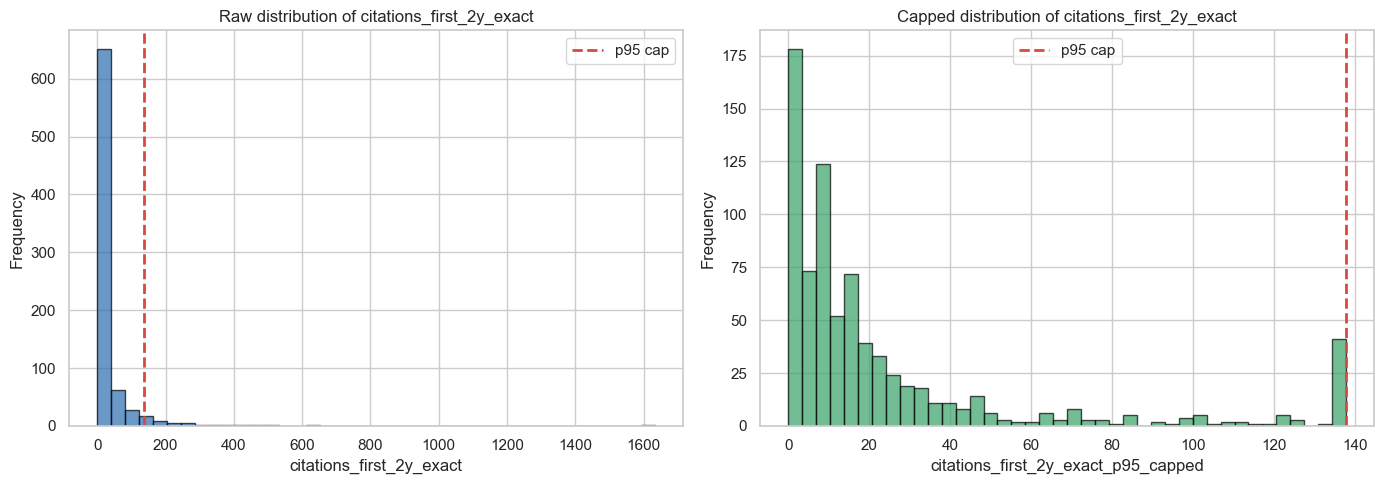


Recommendation:
- Keep zero-citation papers in the training data; they are informative and represent the low-end mass of the target.
- Use the p95-capped target for models sensitive to leverage and heavy tails.
- Use the upper-tail-trimmed sample only as a sensitivity analysis, not as the default production dataset.


In [15]:
# Percentile-based target treatment: keep zeros, cap only the upper extreme tail
# Rationale:
# - Zero citations are valid signal, not missing data.
# - Very large citation counts are the main source of leverage for linear models.
# - We keep a trimmed sensitivity sample for comparison and a capped target for modeling.

LOWER_PERCENTILE = 0.00
UPPER_PERCENTILE = 0.95

if selected_target not in df_clean.columns:
    raise KeyError(f"Target column '{selected_target}' is missing from df_clean.")

pct_lower_bound = target_series.quantile(LOWER_PERCENTILE)
pct_upper_bound = target_series.quantile(UPPER_PERCENTILE)

# Keep zeros explicitly; only cap the upper tail unless a real lower-bound issue appears.
if target_series.min() <= 0:
    pct_lower_bound = 0.0

pct_capped_col = f"{selected_target}_p95_capped"
pct_trimmed_flag = f"{selected_target}_trimmed_flag"

# Winsorized/capped target for downstream modeling experiments
df_clean[pct_capped_col] = target_series.clip(lower=pct_lower_bound, upper=pct_upper_bound)

# Trimmed view for sensitivity analysis: drop only the most extreme upper tail
df_clean[pct_trimmed_flag] = (target_series > pct_upper_bound).astype(int)
trimmed_rows = df_clean.loc[target_series <= pct_upper_bound].copy()
kept_rows = df_clean.loc[target_series <= pct_upper_bound].copy()
zero_citation_rows = int((target_series == 0).sum())
zero_share = zero_citation_rows / len(df_clean) if len(df_clean) else np.nan
trimmed_count = int((target_series > pct_upper_bound).sum())

print("=" * 80)
print("PERCENTILE-BASED TARGET TREATMENT")
print("=" * 80)
print(f"Target: {selected_target}")
print(f"Lower percentile: {LOWER_PERCENTILE:.0%} -> {pct_lower_bound:.2f}")
print(f"Upper percentile: {UPPER_PERCENTILE:.0%} -> {pct_upper_bound:.2f}")
print(f"Zero-citation papers kept: {zero_citation_rows} ({zero_share:.2%} of all rows)")
print(f"Rows trimmed from the upper tail: {trimmed_count}")
print(f"Rows kept for modeling after upper-tail trimming: {len(trimmed_rows)}")

percentile_summary = pd.DataFrame({
    "dataset": ["original", "capped_target", "upper_tail_trimmed"],
    "rows": [len(df_clean), len(df_clean), len(trimmed_rows)],
    "mean_target": [
        float(target_series.mean()),
        float(df_clean[pct_capped_col].mean()),
        float(trimmed_rows[selected_target].mean()),
    ],
    "median_target": [
        float(target_series.median()),
        float(df_clean[pct_capped_col].median()),
        float(trimmed_rows[selected_target].median()),
    ],
    "max_target": [
        float(target_series.max()),
        float(df_clean[pct_capped_col].max()),
        float(trimmed_rows[selected_target].max()),
    ],
})
print("\nPercentile treatment summary:")
print(percentile_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(target_series.dropna(), bins=40, edgecolor="black", alpha=0.7, color="#2b6cb0")
axes[0].axvline(pct_upper_bound, color="#d94841", linestyle="--", linewidth=2, label="p95 cap")
axes[0].set_title(f"Raw distribution of {selected_target}")
axes[0].set_xlabel(selected_target)
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(df_clean[pct_capped_col].dropna(), bins=40, edgecolor="black", alpha=0.7, color="#38a169")
axes[1].axvline(pct_upper_bound, color="#d94841", linestyle="--", linewidth=2, label="p95 cap")
axes[1].set_title(f"Capped distribution of {selected_target}")
axes[1].set_xlabel(pct_capped_col)
axes[1].set_ylabel("Frequency")
axes[1].legend()
plt.tight_layout()
plt.show()

# Recommendation for downstream modeling
print("\nRecommendation:")
print("- Keep zero-citation papers in the training data; they are informative and represent the low-end mass of the target.")
print("- Use the p95-capped target for models sensitive to leverage and heavy tails.")
print("- Use the upper-tail-trimmed sample only as a sensitivity analysis, not as the default production dataset.")
